In [1]:
import sys
print(sys.executable)

/Users/derrick/projects/supply-chain-delivery-analytics/venv/bin/python


# Exploratory KPI Analysis

This notebook analyzes delivery performance in the Olist e-commerce dataset. The objective is to measure logistics reliability, identify delay patterns, and highlight operational risk areas across time, geography, sellers, and product categories.

# A. Imports and Paths

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = REPO_ROOT / "data_processed"

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

# B. Load Cleaned datasets

In [3]:
orders = pd.read_csv(DATA_PROCESSED / "orders_cleaned.csv")
delivered_orders = pd.read_csv(DATA_PROCESSED / "delivered_orders_cleaned.csv")

In [4]:
print("Orders shape:", orders.shape)
print("Delivered orders shape:", delivered_orders.shape)
delivered_orders.head()

Orders shape: (112650, 42)
Delivered orders shape: (110196, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_flag,delivery_days,estimated_delivery_days,delay_days,late_flag,purchase_year,purchase_month,purchase_dayofweek,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,review_score,freight_ratio,price_band,review_submitted_flag,missing_delivery_metrics_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,8.0,15,0.0,0.0,2017,2017-10,Monday,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,4.0,0.290764,Low,1,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,13.0,19,0.0,0.0,2018,2018-07,Tuesday,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,4.0,0.191744,High,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,9.0,26,0.0,0.0,2018,2018-08,Wednesday,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,5.0,0.120200,Premium,1,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,13.0,26,0.0,0.0,2017,2017-11,Saturday,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,5.0,0.604444,Medium,1,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,2.0,12,0.0,0.0,2018,2018-02,Tuesday,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,5.0,0.438191,Low,1,0


In [5]:
# reparse datetime because csv export strips datetime types

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in delivered_orders.columns:
        delivered_orders[col] = pd.to_datetime(delivered_orders[col], errors="coerce")

In [6]:
# rebuild time fields for grouping

delivered_orders["purchase_month"] = delivered_orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
delivered_orders["purchase_year"] = delivered_orders["order_purchase_timestamp"].dt.year

# C. Headline logistics KPIs 

In [7]:
otd_rate = (1 - delivered_orders["late_flag"].mean()) * 100
late_rate = delivered_orders["late_flag"].mean() * 100
avg_delivery_days = delivered_orders["delivery_days"].mean()
avg_delay_days_late_only = delivered_orders.loc[delivered_orders["late_flag"] == 1, "delay_days"].mean()
avg_review_score = delivered_orders["review_score"].mean()

print(f"On-Time Delivery Rate: {otd_rate:.2f}%")
print(f"Late Delivery Rate: {late_rate:.2f}%")
print(f"Average Delivery Days: {avg_delivery_days:.2f}")
print(f"Average Delay Days (Late Orders Only): {avg_delay_days_late_only:.2f}")
print(f"Average Review Score: {avg_review_score:.2f}")

On-Time Delivery Rate: 92.09%
Late Delivery Rate: 7.91%
Average Delivery Days: 12.01
Average Delay Days (Late Orders Only): 8.74
Average Review Score: 4.08


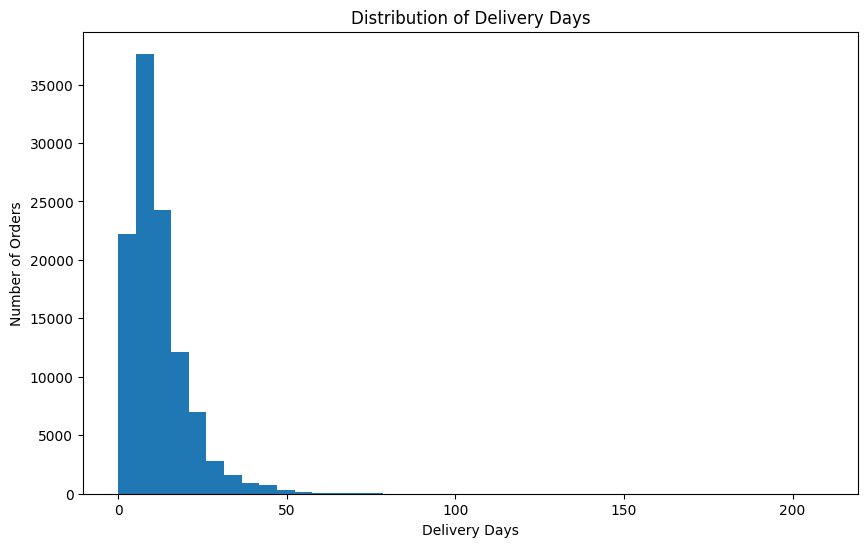

In [8]:
# Distribution of delivery times 1. histogram and boxplot

delivered_orders["delivery_days"].plot(kind="hist", bins=40)
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

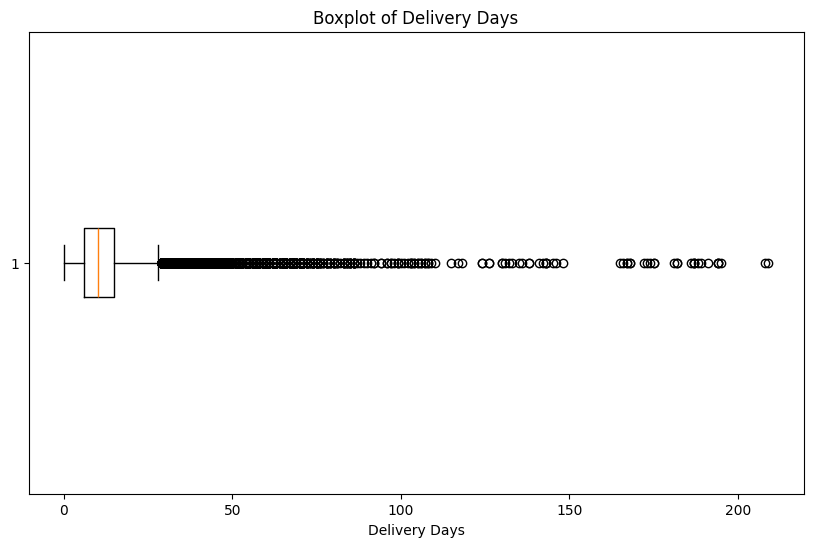

In [9]:
plt.boxplot(delivered_orders["delivery_days"].dropna(), vert=False)
plt.title("Boxplot of Delivery Days")
plt.xlabel("Delivery Days")
plt.show()

### Monthly delivery performance trend

In [10]:
monthly_kpis = delivered_orders.groupby("purchase_month").agg(
    orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("late_flag", "mean")
).reset_index()

monthly_kpis["late_rate"] = monthly_kpis["late_rate"] * 100
monthly_kpis.head()

,purchase_month,orders,avg_delivery_days,late_rate
0,2016-09,3,54.000000,100.000000
1,2016-10,319,19.065831,0.940439
2,2016-12,1,4.000000,0.000000
3,2017-01,913,12.085433,2.847755
4,2017-02,1858,12.612487,3.336921


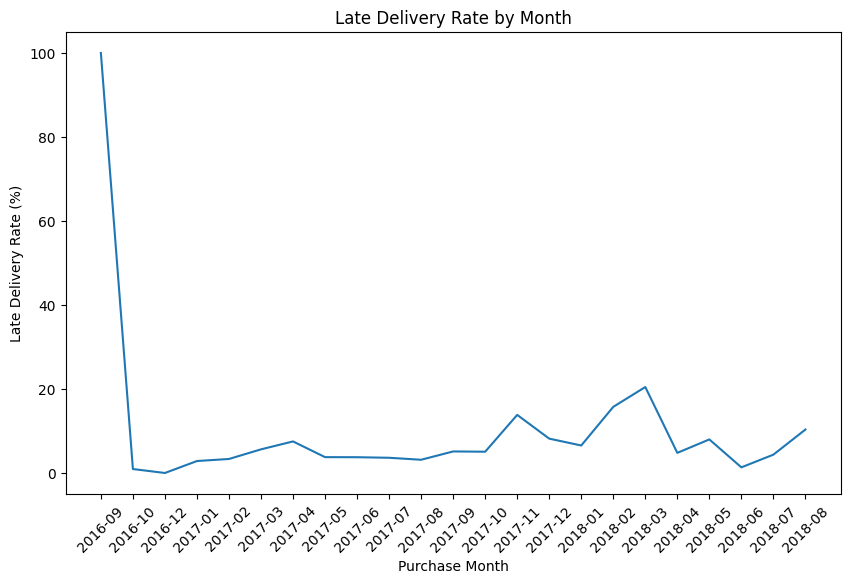

In [11]:
## plot trend for late_rate

plt.plot(monthly_kpis["purchase_month"], monthly_kpis["late_rate"])
plt.title("Late Delivery Rate by Month")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()

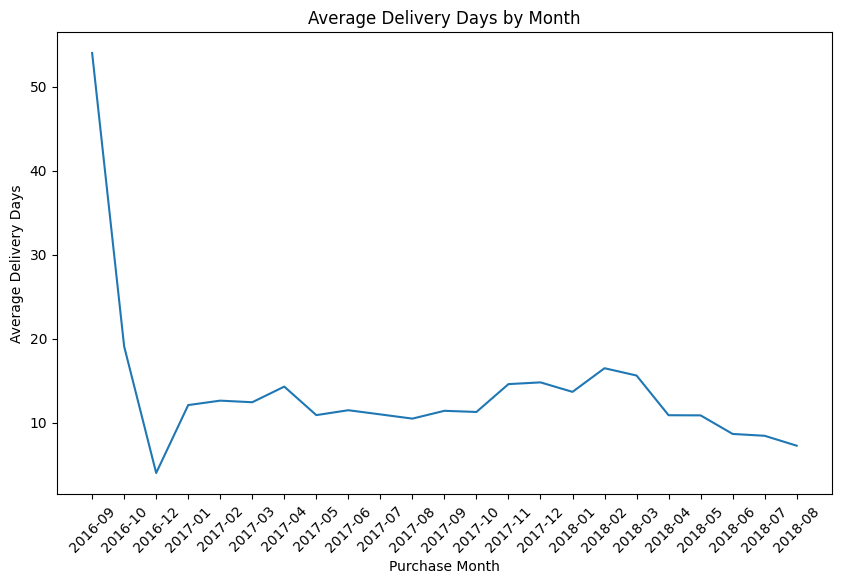

In [12]:
# plot of average delivery days trend

plt.plot(monthly_kpis["purchase_month"], monthly_kpis["avg_delivery_days"])
plt.title("Average Delivery Days by Month")
plt.xlabel("Purchase Month")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=45)
plt.show()

## D. the levels of the state of derlivery (customer perspective)

In [13]:
state_kpis = delivered_orders.groupby("customer_state").agg(
    orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("late_flag", "mean"),
    avg_review_score=("review_score", "mean")
).reset_index()

state_kpis["late_rate"] = state_kpis["late_rate"] * 100
state_kpis = state_kpis.sort_values(by="late_rate", ascending=False)
state_kpis.head(10)

,customer_state,orders,avg_delivery_days,late_rate,avg_review_score
1,AL,427,23.992974,24.121780,3.830189
9,MA,800,21.203750,20.375000,3.758186
24,SE,375,20.978667,16.266667,3.898123
16,PI,523,18.931166,15.487572,3.959459
5,CE,1426,20.537167,15.287518,3.876674
4,BA,3683,18.774640,13.684496,3.862428
18,RJ,14146,14.689382,12.971865,3.873470
13,PA,1054,23.301708,12.428843,3.838491
26,TO,310,17.003226,12.258065,4.155340
7,ES,2225,15.192809,12.224719,4.015953


In [14]:
# filter out outlier sample sizes
state_kpis_filtered = state_kpis[state_kpis["orders"] >= 100]
state_kpis_filtered.head(10)

,customer_state,orders,avg_delivery_days,late_rate,avg_review_score
1,AL,427,23.992974,24.121780,3.830189
9,MA,800,21.203750,20.375000,3.758186
24,SE,375,20.978667,16.266667,3.898123
16,PI,523,18.931166,15.487572,3.959459
5,CE,1426,20.537167,15.287518,3.876674
4,BA,3683,18.774640,13.684496,3.862428
18,RJ,14146,14.689382,12.971865,3.873470
13,PA,1054,23.301708,12.428843,3.838491
26,TO,310,17.003226,12.258065,4.155340
7,ES,2225,15.192809,12.224719,4.015953


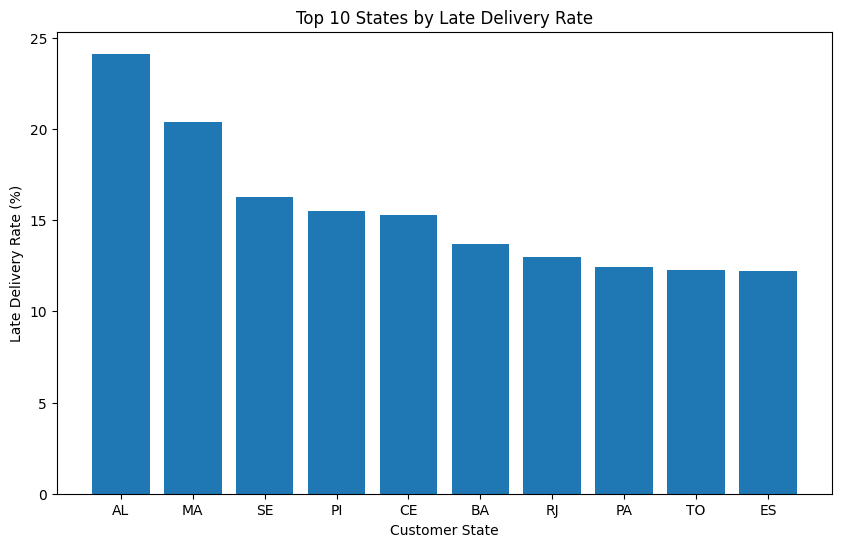

In [15]:
# plot the distribution

top_states = state_kpis_filtered.head(10)

plt.bar(top_states["customer_state"], top_states["late_rate"])
plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.show()

## E. Seller performance analysis

In [16]:
seller_kpis = delivered_orders.groupby("seller_id").agg(
    orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("late_flag", "mean"),
    avg_review_score=("review_score", "mean")
).reset_index()

seller_kpis["late_rate"] = seller_kpis["late_rate"] * 100
seller_kpis = seller_kpis[seller_kpis["orders"] >= 50].sort_values(by="late_rate", ascending=False)
seller_kpis.head(15)

,seller_id,orders,avg_delivery_days,late_rate,avg_review_score
1000,54965bbe3e4f07ae045b90b0b8541f52,81,26.234568,32.098765,3.065789
478,2a1348e9addc1af5aaa619b1a3679d6b,51,26.784314,29.411765,3.040000
1141,6039e27294dc75811c0d8a39069f52c0,74,17.472973,25.675676,3.864865
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,104,16.519231,25.000000,2.971154
1139,602044f2c16190c2c6e45eb35c2e21cb,55,15.345455,23.636364,2.962963
79,06a2c3af7b3aee5d69171b0e14f0ee87,402,17.271144,23.631841,4.022785
2211,beadbee30901a7f61d031b6b686095ad,68,13.058824,23.529412,3.941176
2365,cac4c8e7b1ca6252d8f20b2fc1a2e4af,82,19.426829,23.170732,3.543210
2720,ea566164622c6b439516ab18062c42cd,52,13.807692,23.076923,3.750000
1805,99a54764c341d5dc80b4a8fac4eba3fb,66,6.651515,22.727273,3.507692


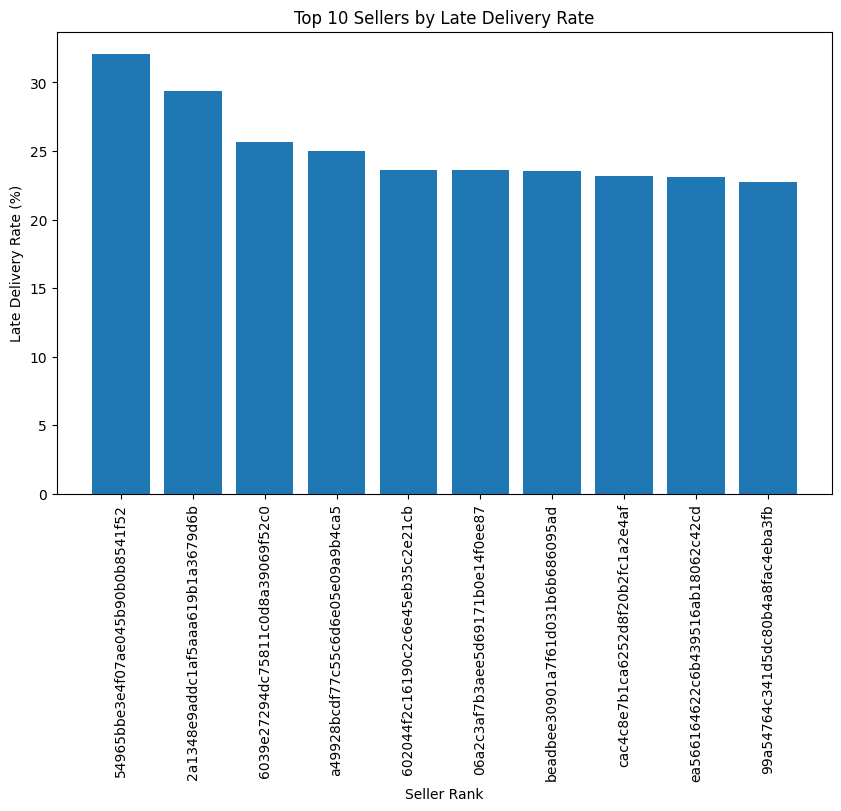

In [17]:
# plot of 10 risky sellers

top_sellers = seller_kpis.head(10)

plt.bar(range(len(top_sellers)), top_sellers["late_rate"])
plt.title("Top 10 Sellers by Late Delivery Rate")
plt.xlabel("Seller Rank")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(range(len(top_sellers)), top_sellers["seller_id"], rotation=90)
plt.show()

## F. Product category analysis

In [18]:
# handle missing values or awakard labels

delivered_orders["product_category_name"] = delivered_orders["product_category_name"].fillna("unknown_category")

In [19]:
# aggregate product category

category_kpis = delivered_orders.groupby("product_category_name").agg(
    orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("late_flag", "mean"),
    avg_review_score=("review_score", "mean")
).reset_index()

category_kpis["late_rate"] = category_kpis["late_rate"] * 100
category_kpis = category_kpis[category_kpis["orders"] >= 100].sort_values(by="late_rate", ascending=False)
category_kpis.head(15)

,product_category_name,orders,avg_delivery_days,late_rate,avg_review_score
7,audio,362,12.883978,12.707182,3.835196
39,fashion_underwear_e_moda_praia,127,13.275591,12.598425,4.047619
6,artigos_de_natal,150,15.300000,12.000000,4.069930
49,livros_tecnicos,263,10.231939,11.026616,4.389313
14,casa_conforto,429,13.039627,10.256410,3.861827
23,construcao_ferramentas_iluminacao,301,9.245847,9.966777,4.082192
1,alimentos,499,9.100200,9.819639,4.262834
30,eletronicos,2729,12.424698,9.747160,4.067159
72,unknown_category,1537,12.314899,9.368900,3.939016
11,beleza_saude,9467,11.516954,9.063061,4.189281


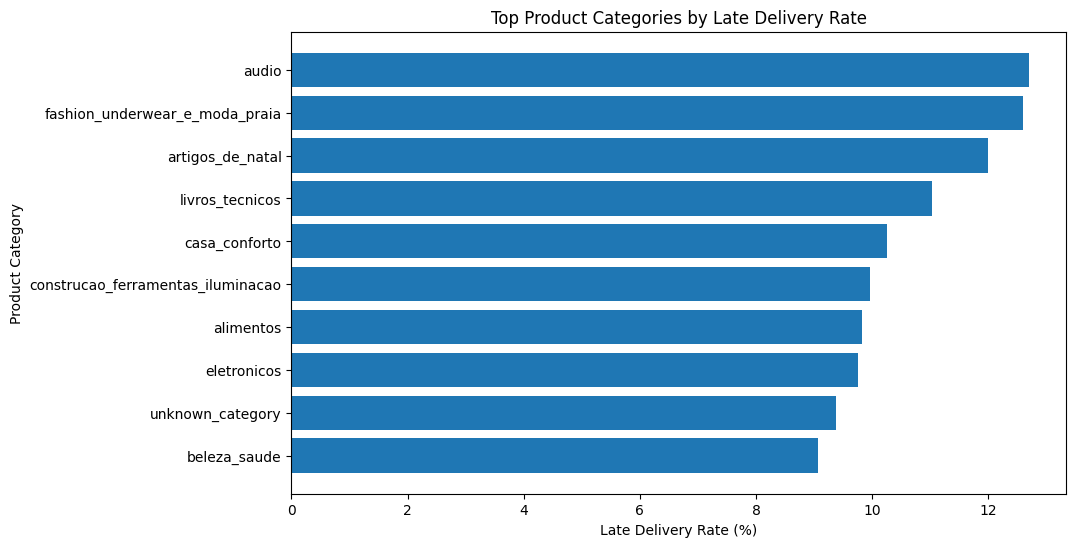

In [20]:
# plot of top categories by delivery rate

top_categories = category_kpis.head(10)

plt.barh(top_categories["product_category_name"], top_categories["late_rate"])
plt.title("Top Product Categories by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.show()

## G. Customer review per delivery delays

In [21]:
review_delay = delivered_orders.groupby("review_score").agg(
    orders=("order_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

review_delay

,review_score,orders,avg_delivery_days,avg_delay_days
0,1.0,12478,19.147700,3.730486
1,2.0,3669,15.348596,1.695012
2,3.0,9184,13.575022,0.719839
3,4.0,21076,11.744781,0.284257
4,5.0,62962,10.183968,0.129999


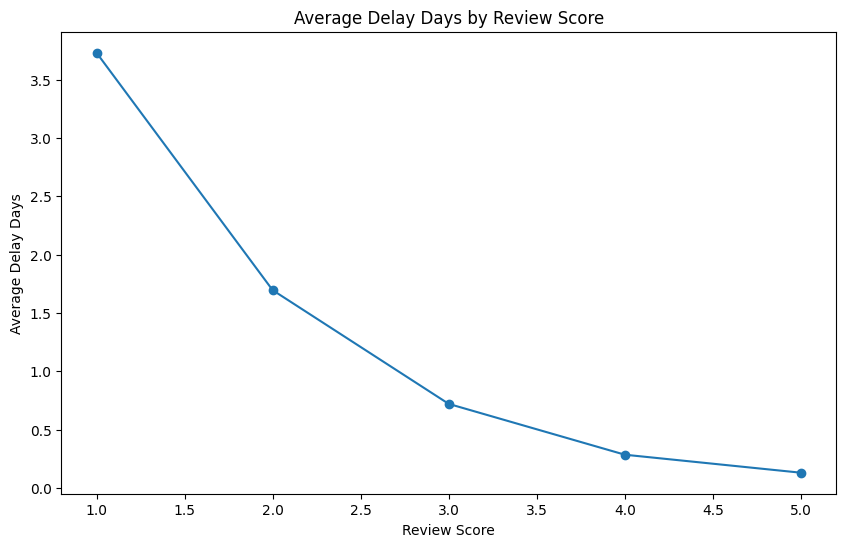

In [22]:
# plot average delays against review scores

plt.plot(review_delay["review_score"], review_delay["avg_delay_days"], marker="o")
plt.title("Average Delay Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delay Days")
plt.show()

In [23]:
network_late_rate = delivered_orders["late_flag"].mean() * 100

state_kpis["late_rate_vs_network"] = state_kpis["late_rate"] - network_late_rate
seller_kpis["late_rate_vs_network"] = seller_kpis["late_rate"] - network_late_rate
category_kpis["late_rate_vs_network"] = category_kpis["late_rate"] - network_late_rate

In [24]:
seller_kpis["risk_band"] = pd.cut(
    seller_kpis["late_rate"],
    bins=[0, 10, 20, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

## H. Export summary tables for Tableau 

In [26]:
# prepare table for export

tableau_export = DATA_PROCESSED / "tableau_exports"
tableau_export.mkdir(parents=True, exist_ok=True)

In [27]:
# export tables
top_problem_states = state_kpis.head(10).copy()
top_problem_sellers = seller_kpis.head(10).copy()
top_problem_categories = category_kpis.head(10).copy()

top_problem_states.to_csv(tableau_export / "top_problem_states.csv", index=False)
top_problem_sellers.to_csv(tableau_export / "top_problem_sellers.csv", index=False)
top_problem_categories.to_csv(tableau_export / "top_problem_categories.csv", index=False)

monthly_kpis.to_csv(tableau_export / "monthly_kpis.csv", index=False)
state_kpis_filtered.to_csv(tableau_export / "state_kpis.csv", index=False)
seller_kpis.to_csv(tableau_export / "seller_kpis.csv", index=False)
category_kpis.to_csv(tableau_export / "category_kpis.csv", index=False)
review_delay.to_csv(tableau_export / "review_delay.csv", index=False)



In [28]:
# checks for no errors

sorted([p.name for p in tableau_export.glob("*.csv")])

['category_kpis.csv',
 'monthly_kpis.csv',
 'review_delay.csv',
 'seller_kpis.csv',
 'state_kpis.csv',
 'top_problem_categories.csv',
 'top_problem_sellers.csv',
 'top_problem_states.csv']